<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Character Level RNN in PyTorch</b>
</h1>
<div style="font-family:'Times New Roman';">
Same RNN as the last notebook but written with torch, and on text instead of a wave. It reads characters one by one and learns to predict the next character, then i let it write text on its own.
</div>

## the data

a small paragraph about ML. every character is one token, so the vocabulary is just the set of characters used in the text.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

text = """machine learning is the study of algorithms that improve with data.
a model learns patterns from examples instead of being programmed with rules.
training means adjusting the weights so that the loss becomes smaller.
the loss tells the model how wrong it is on the training data.
gradient descent moves the weights in the direction that reduces the loss.
a neural network is layers of weights with a non linear function between them.
deep learning is neural networks with many layers stacked together.
overfitting happens when the model memorises the training data.
regularisation and more data are the usual fixes for overfitting.
a recurrent network keeps a hidden state so it can handle sequences."""

chars = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

print("length of text :", len(text))
print("vocab size     :", len(chars))
print("characters     :", "".join(chars))

length of text : 700
vocab size     : 28
characters     : 
 .abcdefghijklmnopqrstuvwxy


## turning text into windows
same idea as the wave, take 25 characters and predict the 26th.

In [2]:
SEQ = 25

data = [stoi[ch] for ch in text]

X, Y = [], []
for i in range(len(data) - SEQ):
    X.append(data[i:i+SEQ])
    Y.append(data[i+SEQ])

X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, Y.shape)
print("example :", repr("".join(itos[i.item()] for i in X[0])), "=> next char", repr(itos[Y[0].item()]))

torch.Size([675, 25]) torch.Size([675])
example : 'machine learning is the s' => next char 't'


## the model

three pieces:

- `nn.Embedding` turns a character id into a small vector, better than one hot
- `nn.RNN` is the loop from notebook 02, already written for us
- `nn.Linear` maps the last hidden state to a score for every character

not using nn.Module, just keeping the three pieces and calling them one after another.

In [3]:
V = len(chars)
EMB, HID = 24, 128

embed = nn.Embedding(V, EMB)
rnn   = nn.RNN(EMB, HID, batch_first=True)
head  = nn.Linear(HID, V)

params = list(embed.parameters()) + list(rnn.parameters()) + list(head.parameters())
print("parameters :", sum(p.numel() for p in params))

parameters : 23996


In [4]:
def run_model(x):
    e = embed(x)               # (batch, seq, emb)
    out, h = rnn(e)            # out is every step, h is the last hidden state
    return head(out[:, -1, :])  # take the last step and score all characters

print(run_model(X[:2]).shape, " = batch of 2, one score per character")

torch.Size([2, 28])  = batch of 2, one score per character


## training
cross entropy, because predicting the next character is a classification over the vocabulary.

In [5]:
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(params, lr=0.005)

hist = []
for epoch in range(600):
    logits = run_model(X)
    loss = loss_fn(logits, Y)

    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(params, 2.0)     # same clipping as the numpy version
    opt.step()

    hist.append(loss.item())
    if epoch % 100 == 0:
        print("epoch", str(epoch).rjust(3), " loss", round(loss.item(), 4))

epoch   0  loss 3.3474


epoch 100  loss 0.0065


epoch 200  loss 0.0015


epoch 300  loss 0.0008


epoch 400  loss 0.0005


epoch 500  loss 0.0003


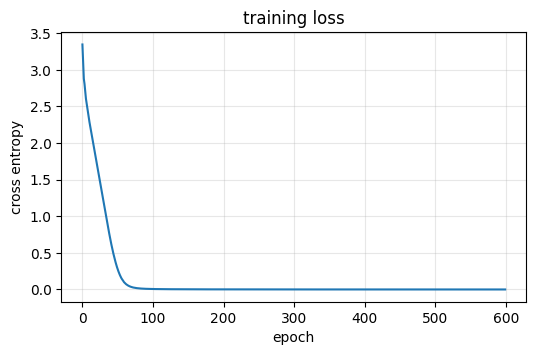

In [7]:
plt.figure(figsize=(6,3.5))
plt.plot(hist)
plt.xlabel('epoch'); plt.ylabel('cross entropy'); plt.grid(alpha=.3)
plt.title('training loss')
plt.show()

In [8]:
with torch.no_grad():
    acc = (run_model(X).argmax(1) == Y).float().mean().item()
print("next character accuracy on the training text :", round(acc * 100, 2), "%")

next character accuracy on the training text : 100.0 %


## making it write

give it a starting string, take the predicted character, add it to the string and repeat.

two ways to pick the next character. **greedy** always takes the highest probability one. **sampling** picks randomly according to the probabilities, and `temperature` controls how wild that is.

one thing that wasted my time here. the seed must be exactly SEQ characters long. i first gave a 24 character seed while the model was trained on 25, and the output was garbage from the very first character. a window of the wrong length is something the model has never seen.

In [13]:
def generate(start, n=200, temperature=0.5, greedy=False):
    out = start
    for i in range(n):
        window = [stoi.get(ch, 0) for ch in out[-SEQ:]]
        x = torch.tensor([window])
        with torch.no_grad():
            logits = run_model(x)
            if greedy:
                nxt = logits.argmax(1).item()
            else:
                probs = torch.softmax(logits / temperature, dim=1)
                nxt = torch.multinomial(probs, 1).item()
        out += itos[nxt]
    return out

seed = text[:SEQ]          # exactly 25 characters, same length as the training windows
print("seed :", repr(seed))
print()
print("GREEDY :")
out = generate(seed, 180, greedy=True)
print(out)
print()
print("does it match the real text :", out == text[:len(out)])

seed : 'machine learning is the s'

GREEDY :
machine learning is the study of algorithms that improve with data.
a model learns patterns from examples instead of being programmed with rules.
training means adjusting the weights so that the loss becom

does it match the real text : True


greedy gives the paragraph back word for word, the match check prints True. that is not learning english, that is memorising, the loss is 0.0003 so the whole paragraph is basicaly stored inside the weights.

## now with sampling

In [10]:
for temp in [0.2, 0.6, 1.2]:
    print("temperature", temp)
    print(generate("the model ", 120, temperature=temp))
    print()

temperature 0.2
the model hemproves the weig layens weights in themdirs atherdsmain todirs.
deecofis the wieg the loss.
areitt mes.
tran the tons 

temperature 0.6
the model hemprre thin the tremurov s stang ateat ov wfigheg themmpeos omear on the tion them rodeneng the with roneteat  mucenc i

temperature 1.2
the model hemoris with monos ofurmeit thes thc modewsts morecutea sog an  mdam reduces thed roc rrann ng morespq k al net liss tea



## what it actually learnt

In [11]:
# how confident is it on a few examples
tests = ["the loss tells the model", "deep learning is neural"]
for s in tests:
    x = torch.tensor([[stoi[ch] for ch in s[-SEQ:]]])
    with torch.no_grad():
        p = torch.softmax(run_model(x), dim=1)[0]
    top = torch.topk(p, 3)
    print(repr(s[-20:]), "=>", [(repr(itos[i.item()]), round(v.item(), 3)) for v, i in zip(top.values, top.indices)])

'loss tells the model' => [("' '", 0.961), ("'s'", 0.038), ("'w'", 0.0)]
'p learning is neural' => [("' '", 0.94), ("'e'", 0.043), ("'o'", 0.004)]


### recap

- `nn.RNN` does in one line what notebook 02 did in 30, the loop inside is exactly the same
- text needs cross entropy and an embedding, the wave needed mse and a raw number, rest is identical
- 100% accuracy but useless generation, wich taught me that train accuracy alone means nothing. the model memorised 10 lines instead of learning english
- greedy output is perfect and sampled output is broken, thats exposure bias, one wrong character puts it in a state it has never seen
- it also cannot hold much beyond a few characters, wich is the vanishing gradient problem. LSTM in the next folder is the fix